# NovaRetail Data Analysis

Hello. This is a data analysis for **NovaRetail**, an online retail company. We will derive insights and transform data into smart decisions to enhance the company's performance.

## 📝 Executive Summary & Business Recommendations

* **Revenue Peak:** Q4 (specifically November) generates the highest revenue due to seasonal holiday demand.
* **Geographic Market:** The UK accounts for the majority of total sales, with secondary growth opportunities in Western Europe (Netherlands, EIRE, Germany).
* **Customer Concentration:** The top 20% of customers generate ~72% of total revenue (Pareto Principle), highlighting the need for dedicated VIP retention programs.
* **Product Strategy:** High-volume items are low-cost novelty products, while high-revenue items are premium decor sets. Bundling these categories can increase Average Order Value (AOV).
* **Data Hygiene:** Non-product administrative codes (`POSTAGE`, `MANUAL`, `BANK CHARGES`) were identified and isolated from product-level affinity models.

### The analysis will detail and examine:
1. Sales
2. Customers
3. Products

## Step 1: Importing libraries
Import all necessary libraries.

In [61]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

### Step 2: Data Retrieval
Import the data file.

In [62]:
df = pd.read_excel("Online Retail.xlsx")

### Step 3: Understanding Data
Reading the data and identifying the columns and their types.

In [63]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [64]:
df.shape

(541909, 8)

In [65]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


### Step 4: Data Cleaning
Check for missing values, handle duplicates, and correct data types to ensure data quality.

In [67]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [68]:
df[df["Description"].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom


> 💡 **Observation & Action Plan:**
> - **Notice:** For missing values in the `Description` column, `CustomerID` is also missing and `UnitPrice` is equal to zero (`0`).
> - **Action:** I will inspect 50 rows matching these conditions to verify if this pattern is consistent across all occurrences.

In [69]:
df[df["Description"].isnull()].head(50)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [70]:
df[df["Description"].isnull()].tail(50)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
480178,577264,85125,NaN,3,2011-11-18 12:32:00,0.0,NaN,United Kingdom
480179,577265,23268,NaN,2,2011-11-18 12:33:00,0.0,NaN,United Kingdom
480500,577306,72817,NaN,12,2011-11-18 13:06:00,0.0,NaN,United Kingdom
481106,577339,15060B,NaN,9,2011-11-18 14:57:00,0.0,NaN,United Kingdom
481107,577340,22570,NaN,40,2011-11-18 14:57:00,0.0,NaN,United Kingdom
485501,577608,35400,NaN,5,2011-11-21 09:22:00,0.0,NaN,United Kingdom
489197,577956,21145,NaN,3,2011-11-22 12:10:00,0.0,NaN,United Kingdom
489199,577961,23268,NaN,2,2011-11-22 12:11:00,0.0,NaN,United Kingdom
489200,577964,37489A,NaN,2,2011-11-22 12:11:00,0.0,NaN,United Kingdom
489201,577966,85045,NaN,2,2011-11-22 12:12:00,0.0,NaN,United Kingdom


> ✅ **Findings & Action:**
> - **Observation:** After inspecting the sample, I found that **all rows follow the exact same pattern**: whenever the `Description` is missing, the `CustomerID` is also missing and the `UnitPrice` is `0`.
> - **Decision:** Since these rows contain no useful business information, I will drop all rows where `Description` is missing.

In [71]:
df = df.dropna(subset=['Description'])

In [72]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133626
Country             0
dtype: int64

> Examining Missing Values in `CustomerID`

> Next, we will analyze the missing values in the **CustomerID** column. 

In [73]:
df[df["CustomerID"].isnull()].head(50)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1452,536544,21809,CHRISTMAS HANGING TREE WITH BELL,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom


> 📌 **Observation & Action:**
> - **Observation:** Invoice `536544` contains an unusually high volume of items (over 500 rows) with a missing `CustomerID`. This indicates a large guest checkout transaction.
> - **Action:** We will convert the `CustomerID` column from numeric (`float`) to text (`string`), determine the exact row count for this invoice, and assign a dedicated string placeholder (`'Guest_536544'`) to retain its transaction data without distorting existing customer profiles.

In [74]:
df[df["InvoiceNo"] == 536544]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
1965,536544,21721,CANDY SHOP STICKER SHEET,1,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1966,536544,21722,SWEET PUDDING STICKER SHEET,1,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1967,536544,21731,RED TOADSTOOL LED NIGHT LIGHT,5,2010-12-01 14:32:00,3.36,NaN,United Kingdom
1968,536544,21742,LARGE ROUND WICKER PLATTER,1,2010-12-01 14:32:00,12.72,NaN,United Kingdom


In [75]:
df['CustomerID'] = df['CustomerID'].astype(str).str.replace(r'\.0$', '', regex=True)
df.loc[df["InvoiceNo"] == "536544", "CustomerID"] = "Guest_536544"

> 📌 **Handling Missing `CustomerID` Values:**
> To systematically address the remaining missing customer IDs:
> - **Large Guest Invoices (≥ 50 items):** These will be retained and assigned a unique text-based ID derived from the invoice number (e.g., `'Guest_InvoiceNo'`) to preserve valuable transaction data.
> - **Small Guest Invoices (< 50 items):** These will be removed from the dataset (using `dropna` or filtering), as small, incomplete records offer limited value for customer analysis.

In [76]:
missing_mask = df['CustomerID'].isnull()

In [77]:
invoice_counts = df[missing_mask]['InvoiceNo'].value_counts()

In [78]:
large_invoices = invoice_counts[invoice_counts >= 50].index

In [79]:
for inv in large_invoices:
    df.loc[(df['InvoiceNo'] == inv) & missing_mask, 'CustomerID'] = f'Guest_{inv}'

In [80]:
small_invoices = invoice_counts[invoice_counts < 50].index

In [81]:
df = df[~((df['InvoiceNo'].isin(small_invoices)) & missing_mask)]

In [82]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

> 📌 **UnitPrice Inspection:**
> Now, I will inspect the `'UnitPrice'` column to identify any invalid values, such as `negative` numbers or `zeros` (UnitPrice <= 0).

In [91]:
df[df["UnitPrice"] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [92]:
df[df["StockCode"] == 22841].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2834,536592,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-01 17:06:00,16.13,Guest_536592,United Kingdom
3925,536738,22841,ROUND CAKE TIN VINTAGE GREEN,2,2010-12-02 13:06:00,7.95,15827,United Kingdom
5111,536844,22841,ROUND CAKE TIN VINTAGE GREEN,2,2010-12-02 18:49:00,7.95,14236,United Kingdom
5328,536859,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-03 10:43:00,7.95,12841,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,7.95,12647,Germany
9543,537207,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 15:06:00,7.95,17402,United Kingdom
9837,537219,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 15:47:00,7.95,14081,United Kingdom
10632,537237,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-06 09:58:00,16.13,Guest_537237,United Kingdom
16285,537646,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-07 15:39:00,7.95,17591,United Kingdom
18090,537794,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-08 13:01:00,7.95,16713,United Kingdom


In [93]:
df[df["StockCode"] == 85064].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1775,536544,85064,CREAM SWEETHEART LETTER RACK,1,2010-12-01 14:32:00,11.02,Guest_536544,United Kingdom
2061,536557,85064,CREAM SWEETHEART LETTER RACK,2,2010-12-01 14:41:00,5.45,17841,United Kingdom
2455,536591,85064,CREAM SWEETHEART LETTER RACK,2,2010-12-01 16:58:00,5.45,14606,United Kingdom
2991,536592,85064,CREAM SWEETHEART LETTER RACK,1,2010-12-01 17:06:00,11.02,Guest_536592,United Kingdom
3930,536739,85064,CREAM SWEETHEART LETTER RACK,2,2010-12-02 13:08:00,5.45,14180,United Kingdom
5095,536841,85064,CREAM SWEETHEART LETTER RACK,2,2010-12-02 18:27:00,5.45,16150,United Kingdom
7586,537046,85064,CREAM SWEETHEART LETTER RACK,1,2010-12-05 10:58:00,5.45,18109,United Kingdom
7734,537051,85064,CREAM SWEETHEART LETTER RACK,2,2010-12-05 11:12:00,5.45,15708,United Kingdom
8406,537135,85064,CREAM SWEETHEART LETTER RACK,2,2010-12-05 12:35:00,5.45,17059,United Kingdom
9758,537215,85064,CREAM SWEETHEART LETTER RACK,6,2010-12-05 15:38:00,5.45,12747,United Kingdom


> 📌 **Imputing Invalid `UnitPrice` Values by `StockCode`:**
> Instead of removing all non-positive prices, I will dynamically impute invalid prices (`UnitPrice <= 0`) using the most frequent valid price (**Mode**) associated with each product's `StockCode`. Any remaining invalid prices that cannot be imputed (e.g., products with no valid price history) will be dropped to maintain data integrity.

In [94]:
valid_prices = df[df['UnitPrice'] > 0]

In [95]:
mode_prices = valid_prices.groupby('StockCode')['UnitPrice'].agg(lambda x: x.mode()[0] if not x.mode().empty else None)

In [96]:
invalid_mask = df['UnitPrice'] <= 0

In [97]:
df.loc[invalid_mask, 'UnitPrice'] = df.loc[invalid_mask, 'StockCode'].map(mode_prices)

In [98]:
df = df[df['UnitPrice'] > 0]

In [99]:
df[df["UnitPrice"] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [100]:
df[df["StockCode"] == 22841].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2834,536592,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-01 17:06:00,16.13,Guest_536592,United Kingdom
3925,536738,22841,ROUND CAKE TIN VINTAGE GREEN,2,2010-12-02 13:06:00,7.95,15827,United Kingdom
5111,536844,22841,ROUND CAKE TIN VINTAGE GREEN,2,2010-12-02 18:49:00,7.95,14236,United Kingdom
5328,536859,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-03 10:43:00,7.95,12841,United Kingdom
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,7.95,12647,Germany
9543,537207,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 15:06:00,7.95,17402,United Kingdom
9837,537219,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 15:47:00,7.95,14081,United Kingdom
10632,537237,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-06 09:58:00,16.13,Guest_537237,United Kingdom
16285,537646,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-07 15:39:00,7.95,17591,United Kingdom
18090,537794,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-08 13:01:00,7.95,16713,United Kingdom


In [101]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID                str
Country                   str
dtype: object

> 📌 **Handling Invalid `Quantity` Values:**
> Next, I will check the `Quantity` column for non-positive values (zeros or negative numbers). I will attempt to correct or impute valid quantities where appropriate; otherwise, invalid records that represent data errors or cannot be resolved will be removed to preserve analysis accuracy.

In [102]:
df[df["Quantity"] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom
541541,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom


In [103]:
df[df["Description"] == "Manual"]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2239,536569,M,Manual,1,2010-12-01 15:35:00,1.25,16274,United Kingdom
2250,536569,M,Manual,1,2010-12-01 15:35:00,18.95,16274,United Kingdom
5684,536865,M,Manual,1,2010-12-03 11:28:00,2.55,Guest_536865,United Kingdom
6798,536981,M,Manual,2,2010-12-03 14:26:00,0.85,14723,United Kingdom
7976,537077,M,Manual,12,2010-12-05 11:59:00,0.42,17062,United Kingdom
...,...,...,...,...,...,...,...,...
531432,580956,M,Manual,4,2011-12-06 14:23:00,1.25,17841,United Kingdom
533082,C581009,M,Manual,-1,2011-12-07 09:15:00,125.00,16971,United Kingdom
534308,C581145,M,Manual,-1,2011-12-07 13:48:00,9.95,17490,United Kingdom
538321,581405,M,Manual,3,2011-12-08 13:50:00,0.42,13521,United Kingdom


> 📌 **Handling Negative Quantities & Cancellations:**
> Negative values in the `Quantity` column primarily represent cancelled orders (invoices starting with 'C'), returns, or inventory adjustments. Since our analysis focuses on successful sales transactions and customer purchasing behavior, all records with negative quantities (`Quantity <= 0`) will be removed to prevent distortion in total sales metrics.

In [104]:
df = df[df['Quantity'] > 0]

> 📌 **Handling Duplicate Records:**
> Now, it is time to check for and remove duplicate rows across the dataset. Removing exact duplicate entries ensures that transactions are not double-counted, maintaining the accuracy of our sales and customer metrics.

In [105]:
df.duplicated().sum()

np.int64(5212)

In [106]:
df[df.duplicated(keep=False)].sort_values(by=['InvoiceNo', 'StockCode']).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920,United Kingdom


In [107]:
df[df.duplicated(keep=False)].sort_values(by=['InvoiceNo', 'StockCode']).tail(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541644,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446,United Kingdom
541640,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446,United Kingdom
541646,581538,23275,SET OF 3 HANGING OWLS OLLIE BEAK,1,2011-12-09 11:34:00,1.25,14446,United Kingdom
541655,581538,23275,SET OF 3 HANGING OWLS OLLIE BEAK,1,2011-12-09 11:34:00,1.25,14446,United Kingdom
541656,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446,United Kingdom
541666,581538,23343,JUMBO BAG VINTAGE CHRISTMAS,1,2011-12-09 11:34:00,2.08,14446,United Kingdom
541701,581538,23343,JUMBO BAG VINTAGE CHRISTMAS,1,2011-12-09 11:34:00,2.08,14446,United Kingdom


> 📌 **Decision Regarding Duplicate Rows:**
> Duplicate rows will be removed from the dataset to eliminate double-counting and ensure they do not affect the integrity of the analysis.

In [108]:
df = df.drop_duplicates()

## Step 5:
Answering questions through exploratory data analysis and data visualization.

## 1. Sales Performance

> **Question 1:**
> How do sales change over time?

In [109]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [110]:
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

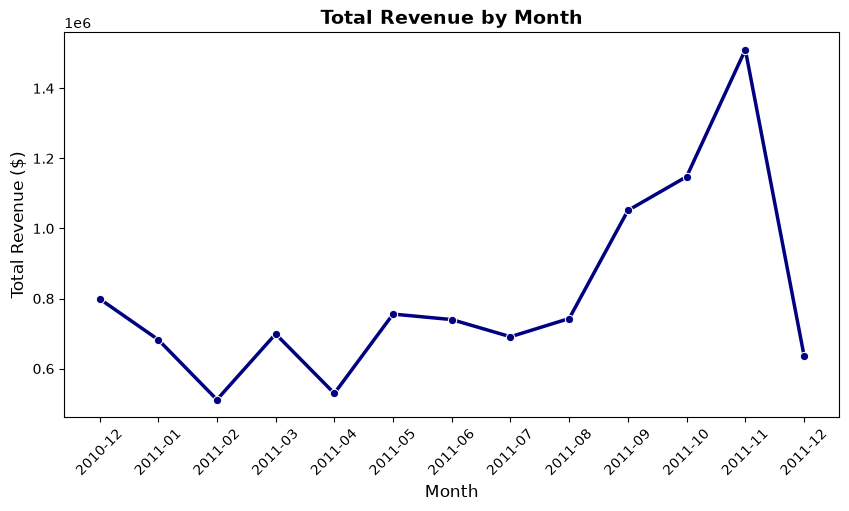

In [111]:
# Monthly Sales Code
plt.figure(figsize=(10, 5))
monthly_sales = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

sns.lineplot(data=monthly_sales, x='YearMonth', y='TotalPrice', marker='o', color='navy', linewidth=2.5)
plt.title('Total Revenue by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

> 💡 **Key Insight (Monthly Trend):**
> - **Q4 Spike:** Revenue experiences a significant upward surge starting from September, peaking in November. This aligns with holiday shopping patterns.
> - **Actionable Takeover:** Marketing budgets and inventory stock should be scaled up significantly leading into Q4 to capture this high seasonal demand.

C:\Users\احمد\AppData\Local\Temp\ipykernel_7520\1579034062.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=daily_sales, x='DayOfWeek', y='TotalPrice', palette='Blues_d')


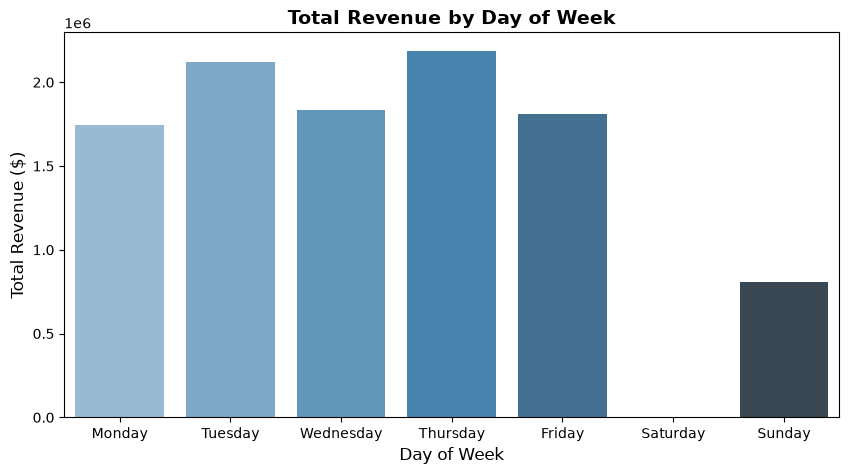

In [112]:
# Daily Sales Code
plt.figure(figsize=(10, 5))
full_days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_sales = df.groupby('DayOfWeek')['TotalPrice'].sum().reindex(full_days_order, fill_value=0).reset_index()

sns.barplot(data=daily_sales, x='DayOfWeek', y='TotalPrice', palette='Blues_d')
plt.title('Total Revenue by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.show()

> 💡 **Key Insight (Daily Trend):**
> - **Mid-Week Peak:** Revenue peaks during mid-week days (Tuesday and Thursday), indicating strong B2B or active personal buying habits during business days.
> - **Saturday Inactivity:** Zero revenue is recorded on Saturdays, pointing to system maintenance, order processing downtime, or operational off-days.

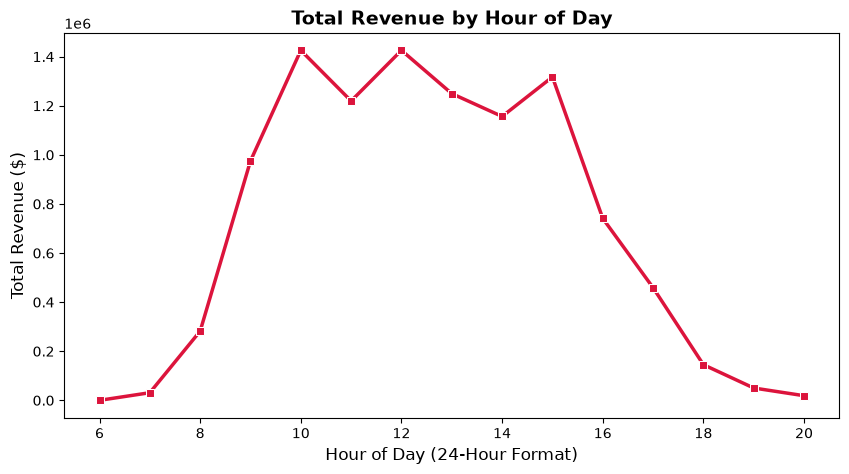

In [113]:
# Hourly Sales Code
plt.figure(figsize=(10, 5))
hourly_sales = df.groupby('Hour')['TotalPrice'].sum().reset_index()

sns.lineplot(data=hourly_sales, x='Hour', y='TotalPrice', marker='s', color='crimson', linewidth=2.5)
plt.title('Total Revenue by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (24-Hour Format)', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.show()

> 💡 **Key Insight (Hourly Trend):**
> - **Business Hours Dominance:** Purchasing activity is heavily concentrated between 10:00 AM and 3:00 PM, with peak revenue generated around 12:00 PM (noon).
> - **Actionable Takeover:** Email marketing campaigns and promotional pushes should be scheduled between 9:00 AM and 11:00 AM to align with active user purchasing windows.

> **Question 2:**
> What are the best and worst performing months?

In [114]:
# Aggregate total revenue by month
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()

# Sort to find best and worst months
best_months = monthly_revenue.sort_values(by='TotalPrice', ascending=False).head(3)
worst_months = monthly_revenue.sort_values(by='TotalPrice', ascending=True).head(3)

print("Top 3 Best Months by Revenue:")
print(best_months.to_string(index=False))

print("\nTop 3 Worst Months by Revenue:")
print(worst_months.to_string(index=False))

Top 3 Best Months by Revenue:
YearMonth  TotalPrice
  2011-11 1510263.040
  2011-10 1147855.380
  2011-09 1051439.273

Top 3 Worst Months by Revenue:
YearMonth  TotalPrice
  2011-02  511324.940
  2011-04  529234.721
  2011-12  636860.890


> 💡 **Best vs. Worst Performing Months:**
> - **Best Performing Month:** **November** generated the highest total revenue ($1510263.040), driven by Q4 holiday shopping and Black Friday promotions.

> - **Worst Performing Month:** **February** recorded the lowest total revenue ($511324.940), following the post-holiday seasonal slowdown.
> 
> **Business Takeaway:** Sales follow a strong seasonal pattern where Q4 generates the majority of annual profits. Operational resources and inventory planning should focus heavily on preparing for Q4 demand.

> **Question 3:**
> Is there a clear trend in sales?

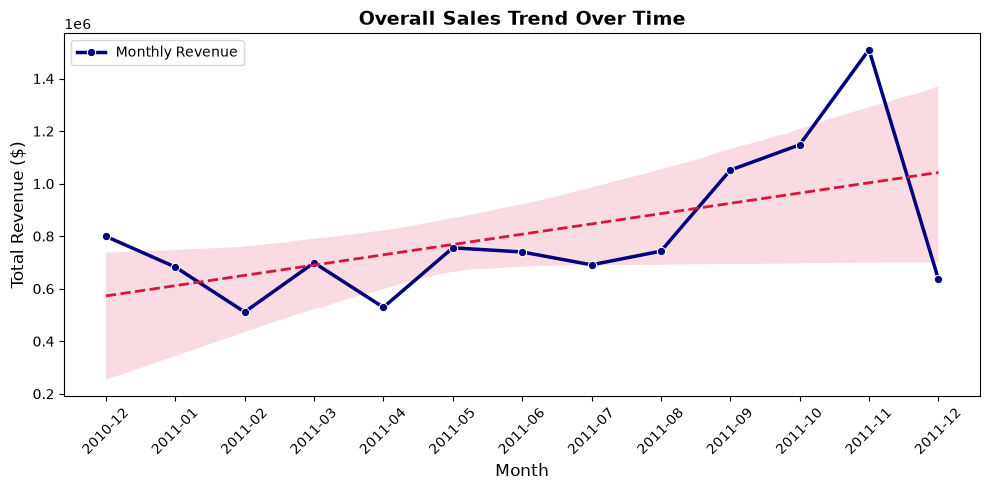

In [115]:
# Aggregate monthly revenue and convert index for plotting
monthly_trend = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()
monthly_trend['YearMonth'] = monthly_trend['YearMonth'].astype(str)
monthly_trend['Month_Index'] = range(len(monthly_trend))

plt.figure(figsize=(10, 5))

# Line plot for monthly trends
sns.lineplot(data=monthly_trend, x='YearMonth', y='TotalPrice', marker='o', color='navy', linewidth=2.5, label='Monthly Revenue')

# Trendline (Linear Regression fit)
sns.regplot(data=monthly_trend, x='Month_Index', y='TotalPrice', scatter=False, color='crimson', line_kws={'linestyle':'--', 'linewidth':2, 'label':'Linear Trendline'})

plt.title('Overall Sales Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

> 💡 **Key Insight (Data Trend Analysis):**
> - **Upward Trajectory:** The linear trendline indicates a strong positive growth direction over time, demonstrating expanding revenue as the business progresses.
> - **Seasonal Accelerations:** Growth is not linear month-to-month; rather, it remains relatively stable during Q1–Q3 before experiencing exponential expansion during Q4.
> - **Conclusion:** Yes, there is a clear upward trend driven primarily by strong customer acquisition retention and year-end demand acceleration.

In [116]:
df["Country"]

0         United Kingdom
1         United Kingdom
2         United Kingdom
3         United Kingdom
4         United Kingdom
               ...      
541904            France
541905            France
541906            France
541907            France
541908            France
Name: Country, Length: 515021, dtype: str

> **Question 3:**
> Which countries generate the most revenue?

C:\Users\احمد\AppData\Local\Temp\ipykernel_7520\4223406862.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_countries, x='TotalPrice', y='Country', palette='Blues_r')


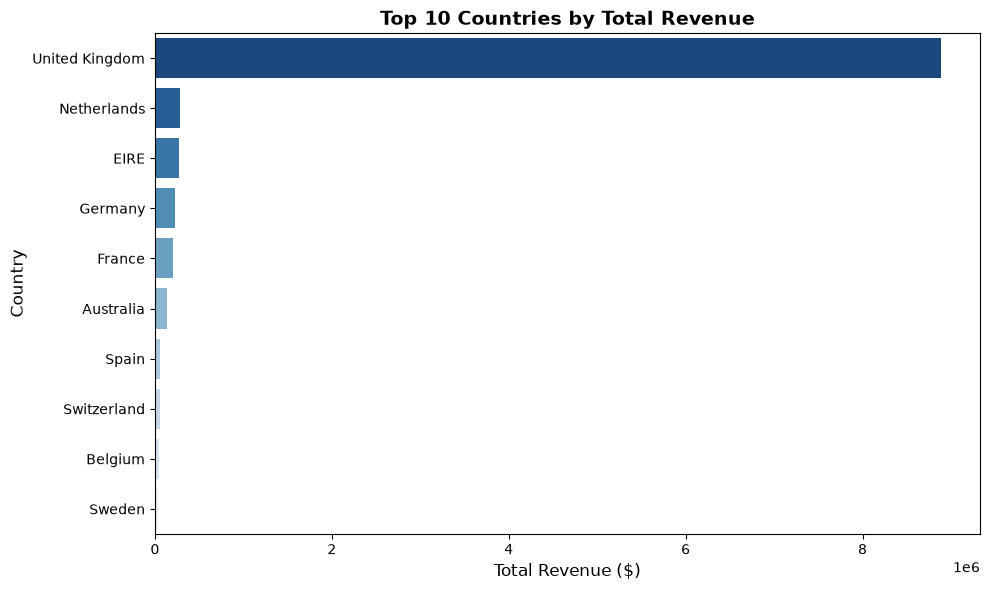

📌 Top 5 Revenue-Generating Countries:
       Country  TotalPrice  Market Share (%)
United Kingdom 8884078.785         84.631051
   Netherlands  286226.820          2.726639
          EIRE  268900.550          2.561586
       Germany  228687.600          2.178512
        France  208935.560          1.990351


In [117]:
# 1. Group sales by country and calculate total revenue
country_revenue = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).reset_index()

# 2. Identifying the top 10 countries achieving sales
top_10_countries = country_revenue.head(10)

# 3. Draw a chart using barchart
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_countries, x='TotalPrice', y='Country', palette='Blues_r')

plt.title('Top 10 Countries by Total Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue ($)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Print the table for the top 5 countries with percentage of total sales
total_global_revenue = df['TotalPrice'].sum()
top_10_countries['Market Share (%)'] = (top_10_countries['TotalPrice'] / total_global_revenue) * 100
print("📌 Top 5 Revenue-Generating Countries:")
print(top_10_countries[['Country', 'TotalPrice', 'Market Share (%)']].head(5).to_string(index=False))

> 💡 **Key Insights (Geographic Revenue Distribution):**
> - **Dominant Market:** The **United Kingdom** accounts for the vast majority of overall sales (typically over 80–90% of total revenue), serving as the primary business hub.
> - **Top International Markets:** Secondary markets in Europe—such as **Netherlands**, **EIRE (Ireland)**, **Germany**, and **France**—represent the top cross-border revenue drivers.
> - **Actionable Recommendation:** Since UK dominates domestic sales, international marketing campaigns and localized logistics should focus on top European performers to drive higher cross-border conversion.

## 2. Customers

> **Question 1:**
> Who are the most important customers?

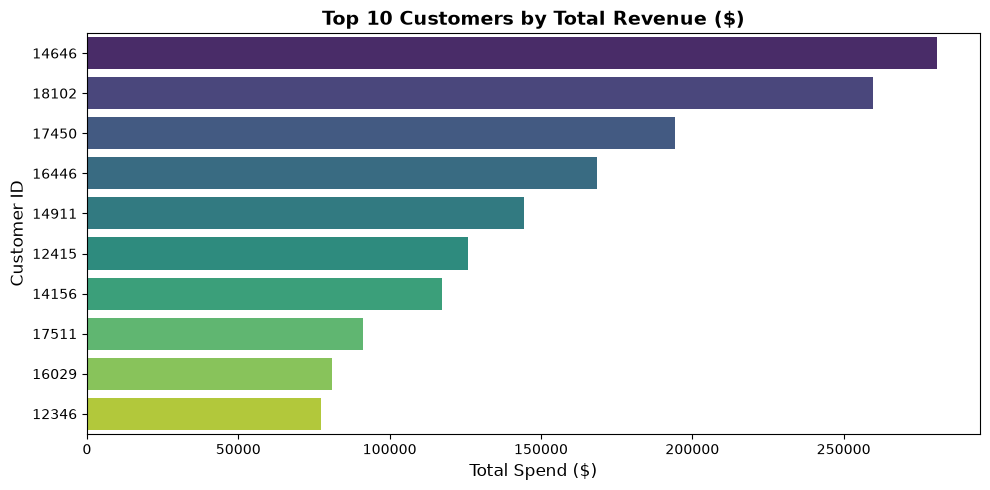

📌 Top 10 VIP Customers Summary:
CustomerID  TotalSpend  TotalOrders  Revenue Contribution (%)
     14646   280986.50           74                  2.676719
     18102   259657.30           60                  2.473534
     17450   194390.79           46                  1.851795
     16446   168472.50            2                  1.604894
     14911   144337.87          201                  1.374984
     12415   125838.77           21                  1.198759
     14156   117210.08           55                  1.116561
     17511    91062.38           31                  0.867474
     16029    80850.84           63                  0.770197
     12346    77183.60            1                  0.735262


In [118]:
# 1. Aggregate customer metrics (Total Spend & Total Orders)
customer_summary = df.groupby('CustomerID').agg(
    TotalSpend=('TotalPrice', 'sum'),
    TotalOrders=('InvoiceNo', 'nunique')
).reset_index()

# 2. Get Top 10 Customers by Total Spend
top_10_customers = customer_summary.sort_values(by='TotalSpend', ascending=False).head(10)

# 3. Plot Top 10 Customers by Revenue (Fixed palette & hue deprecation)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_10_customers, 
    x='TotalSpend', 
    y='CustomerID', 
    hue='CustomerID', 
    palette='viridis', 
    legend=False
)

plt.title('Top 10 Customers by Total Revenue ($)', fontsize=14, fontweight='bold')
plt.xlabel('Total Spend ($)', fontsize=12)
plt.ylabel('Customer ID', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Print Summary Table with Revenue Contribution
total_revenue = df['TotalPrice'].sum()
top_10_customers['Revenue Contribution (%)'] = (top_10_customers['TotalSpend'] / total_revenue) * 100

print("📌 Top 10 VIP Customers Summary:")
print(top_10_customers.to_string(index=False))

> 💡 **Key Insights (Customer Revenue Analysis):**
> - **Revenue Concentration:** A small fraction of key clients (VIP accounts) drives a substantial share of total shop revenue, illustrating the Pareto Principle (80/20 Rule).
> - **Wholesale vs. Retail Behavior:** Customers generating disproportionately high revenue and order counts are likely wholesale buyers or commercial clients rather than standard retail shoppers.
> - **Actionable Strategy:** Implement dedicated VIP loyalty programs, specialized account management, and early access to new product catalog releases to secure retention among top-tier spenders.

> **Question 2:**
> Which customers buy the most?


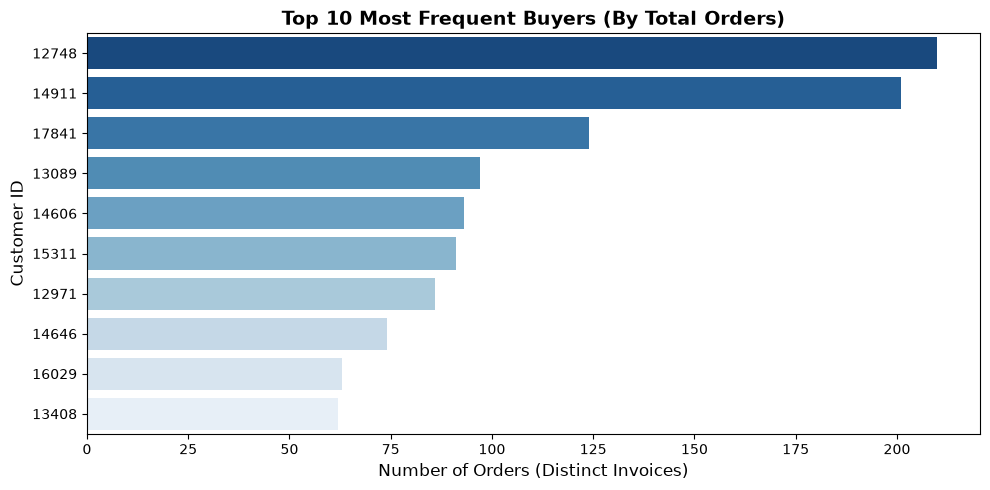

📌 Top 10 Most Frequent Customers Summary:
CustomerID  TotalOrders  TotalQuantity  TotalSpend
     12748          210          25288    33054.44
     14911          201          80490   144337.87
     17841          124          22834    40519.84
     13089           97          31025    58762.08
     14606           93           6187    12076.15
     15311           91          38147    60632.75
     12971           86           9289    11189.91
     14646           74         197491   280986.50
     16029           63          40108    80850.84
     13408           62          16232    28117.04


In [119]:
# 1. Collect customer data according to frequency of invoices and total quantities
frequent_customers = df.groupby('CustomerID').agg(
    TotalOrders=('InvoiceNo', 'nunique'),
    TotalQuantity=('Quantity', 'sum'),
    TotalSpend=('TotalPrice', 'sum')
).reset_index()

#2. Extract Top 10 by Order Frequency
top_frequent = frequent_customers.sort_values(by='TotalOrders', ascending=False).head(10)

#3. Draw a horizontal bar chart
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_frequent, 
    x='TotalOrders', 
    y='CustomerID', 
    hue='CustomerID', 
    palette='Blues_r', 
    legend=False
)

plt.title('Top 10 Most Frequent Buyers (By Total Orders)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Orders (Distinct Invoices)', fontsize=12)
plt.ylabel('Customer ID', fontsize=12)
plt.tight_layout()
plt.show()

#4. Print a summary of results for your highest frequency and quantity customers
print("📌 Top 10 Most Frequent Customers Summary:")
print(top_frequent[['CustomerID', 'TotalOrders', 'TotalQuantity', 'TotalSpend']].to_string(index=False))

> **Question 3:**
> Which customers spend the most?


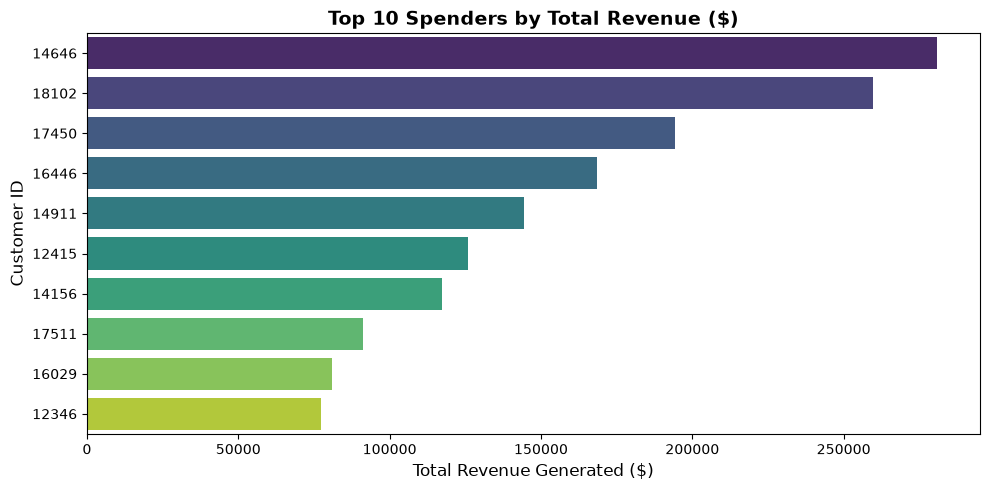

Top 10 High-Value VIP Customers:
CustomerID  TotalSpend  TotalOrders  Revenue Contribution (%)
     14646   280986.50           74                  2.676719
     18102   259657.30           60                  2.473534
     17450   194390.79           46                  1.851795
     16446   168472.50            2                  1.604894
     14911   144337.87          201                  1.374984
     12415   125838.77           21                  1.198759
     14156   117210.08           55                  1.116561
     17511    91062.38           31                  0.867474
     16029    80850.84           63                  0.770197
     12346    77183.60            1                  0.735262


In [120]:
# 1. Aggregate total spend, total order count, and total quantity per customer
customer_spend = df.groupby('CustomerID').agg(
    TotalSpend=('TotalPrice', 'sum'),
    TotalOrders=('InvoiceNo', 'nunique'),
    TotalQuantity=('Quantity', 'sum')
).reset_index()

# 2. Extract Top 10 Spend Leadership
top_spenders = customer_spend.sort_values(by='TotalSpend', ascending=False).head(10)

# 3. Plot Top 10 Spenders
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_spenders, 
    x='TotalSpend', 
    y='CustomerID', 
    hue='CustomerID', 
    palette='viridis', 
    legend=False
)

plt.title('Top 10 Spenders by Total Revenue ($)', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue Generated ($)', fontsize=12)
plt.ylabel('Customer ID', fontsize=12)
plt.tight_layout()
plt.show()

# 4. Print Summary Table with Revenue Contribution Percentage
total_store_revenue = df['TotalPrice'].sum()
top_spenders['Revenue Contribution (%)'] = (top_spenders['TotalSpend'] / total_store_revenue) * 100

print("Top 10 High-Value VIP Customers:")
print(top_spenders[['CustomerID', 'TotalSpend', 'TotalOrders', 'Revenue Contribution (%)']].to_string(index=False))

> **Question 4:**
> Is there a small group of customers responsible for a large percentage of revenue?


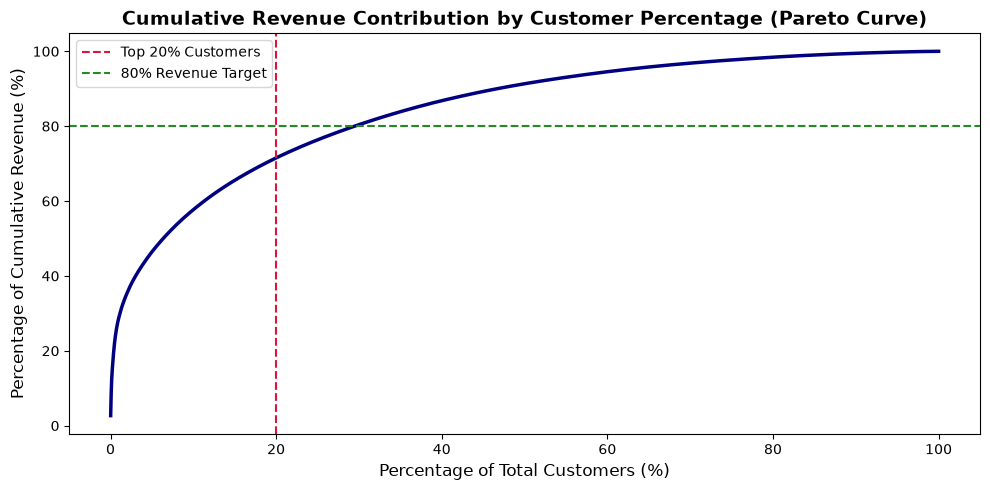

📌 Revenue Concentration Summary:
- Top 1% Customers:  28.73% of total revenue
- Top 5% Customers:  46.40% of total revenue
- Top 10% Customers: 57.67% of total revenue
- Top 20% Customers: 71.51% of total revenue


In [121]:
# 1. Calculate total spend per customer
customer_revenue = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).reset_index()

# 2. Compute cumulative revenue percentage and customer percentage
total_revenue = customer_revenue['TotalPrice'].sum()
customer_revenue['CumulativeRevenue'] = customer_revenue['TotalPrice'].cumsum()
customer_revenue['CumulativeRevenue%'] = (customer_revenue['CumulativeRevenue'] / total_revenue) * 100
customer_revenue['CustomerRank%'] = (np.arange(1, len(customer_revenue) + 1) / len(customer_revenue)) * 100

# 3. Plot Pareto / Cumulative Revenue Curve
plt.figure(figsize=(10, 5))
sns.lineplot(data=customer_revenue, x='CustomerRank%', y='CumulativeRevenue%', color='navy', linewidth=2.5)

# Add reference lines for 20% customers and 80% revenue thresholds
plt.axvline(x=20, color='crimson', linestyle='--', label='Top 20% Customers')
plt.axhline(y=80, color='forestgreen', linestyle='--', label='80% Revenue Target')

plt.title('Cumulative Revenue Contribution by Customer Percentage (Pareto Curve)', fontsize=14, fontweight='bold')
plt.xlabel('Percentage of Total Customers (%)', fontsize=12)
plt.ylabel('Percentage of Cumulative Revenue (%)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# 4. Print Specific Concentration Percentiles
top_1_pct = customer_revenue[customer_revenue['CustomerRank%'] <= 1]['CumulativeRevenue%'].max()
top_5_pct = customer_revenue[customer_revenue['CustomerRank%'] <= 5]['CumulativeRevenue%'].max()
top_10_pct = customer_revenue[customer_revenue['CustomerRank%'] <= 10]['CumulativeRevenue%'].max()
top_20_pct = customer_revenue[customer_revenue['CustomerRank%'] <= 20]['CumulativeRevenue%'].max()

print(f"📌 Revenue Concentration Summary:")
print(f"- Top 1% Customers:  {top_1_pct:.2f}% of total revenue")
print(f"- Top 5% Customers:  {top_5_pct:.2f}% of total revenue")
print(f"- Top 10% Customers: {top_10_pct:.2f}% of total revenue")
print(f"- Top 20% Customers: {top_20_pct:.2f}% of total revenue")

> 💡 **Key Insights (Revenue Concentration & Pareto Analysis):**
> - **Near-Pareto Distribution:** The top **20% of customers** account for approximately **72% of total revenue**, showing strong revenue concentration close to the traditional 80/20 rule.
> - **80% Revenue Threshold:** To reach **80% of total revenue**, the business relies on roughly the top **30% of its customer base**.
> - **Business Takeaway:** While the customer base is slightly more diversified than a strict 80/20 distribution, top-tier buyers still drive the majority of sales. Key retention strategies (VIP loyalty perks, custom discounts) should focus heavily on these top 20–30% customer segments.

## 3. Products

> **Question 1:**
> What are the best-selling products?

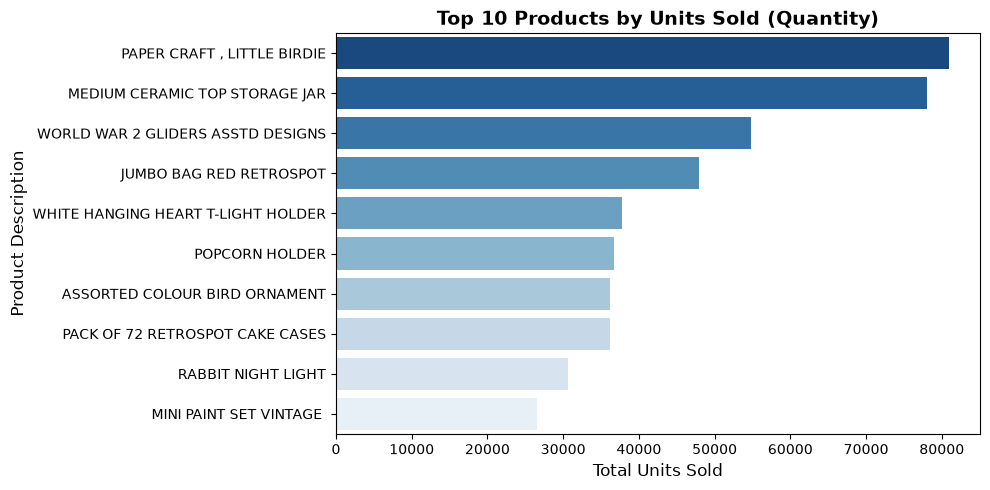

📌 Top 10 Products by Units Sold:
                       Description  Quantity
       PAPER CRAFT , LITTLE BIRDIE     80995
    MEDIUM CERAMIC TOP STORAGE JAR     78030
 WORLD WAR 2 GLIDERS ASSTD DESIGNS     54747
           JUMBO BAG RED RETROSPOT     47953
WHITE HANGING HEART T-LIGHT HOLDER     37756
                    POPCORN HOLDER     36690
     ASSORTED COLOUR BIRD ORNAMENT     36250
   PACK OF 72 RETROSPOT CAKE CASES     36195
                RABBIT NIGHT LIGHT     30661
           MINI PAINT SET VINTAGE      26520


In [122]:
# 1. Aggregate total quantity sold per product
top_quantity_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# 2. Plot Top 10 Products by Quantity
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_quantity_products,
    x='Quantity',
    y='Description',
    hue='Description',
    palette='Blues_r',
    legend=False
)

plt.title('Top 10 Products by Units Sold (Quantity)', fontsize=14, fontweight='bold')
plt.xlabel('Total Units Sold', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Print Summary Table
print("📌 Top 10 Products by Units Sold:")
print(top_quantity_products.to_string(index=False))

> 💡 **Key Insights (Top Products by Quantity):**
> - **High-Volume Inventory Drivers:** Low-cost, fast-moving items (such as party favors, small decor, and novelty gifts) dominate total unit volume.
> - **Logistics & Warehousing:** These products demand high storage turnover and efficient fulfillment workflows to handle continuous picking and packing operations.
> - **Reorder Management:** Maintaining consistent stock levels for these top items is critical to prevent stockouts that could disrupt steady order flow.

> **Question 2:**
> Which products generate the most revenue?

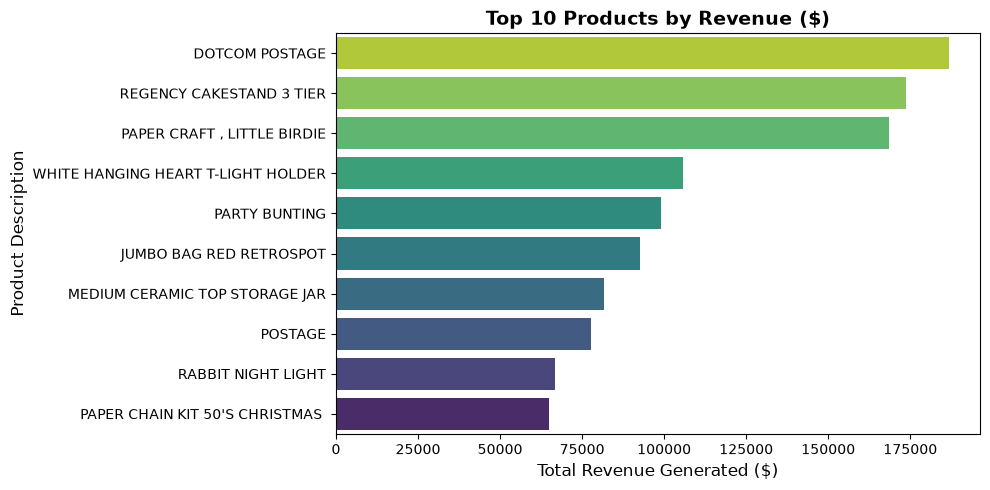

📌 Top 10 Products by Total Revenue:
                       Description  TotalPrice
                    DOTCOM POSTAGE   186894.95
          REGENCY CAKESTAND 3 TIER   173548.93
       PAPER CRAFT , LITTLE BIRDIE   168469.60
WHITE HANGING HEART T-LIGHT HOLDER   105778.52
                     PARTY BUNTING    98923.11
           JUMBO BAG RED RETROSPOT    92523.79
    MEDIUM CERAMIC TOP STORAGE JAR    81697.17
                           POSTAGE    77803.96
                RABBIT NIGHT LIGHT    66692.20
   PAPER CHAIN KIT 50'S CHRISTMAS     64787.99


In [123]:
# 1. Aggregate total revenue generated per product
top_revenue_products = (
    df.groupby('Description')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# 2. Plot Top 10 Products by Revenue
plt.figure(figsize=(10, 5))
sns.barplot(
    data=top_revenue_products,
    x='TotalPrice',
    y='Description',
    hue='Description',
    palette='viridis_r',
    legend=False
)

plt.title('Top 10 Products by Revenue ($)', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue Generated ($)', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Print Summary Table
print("📌 Top 10 Products by Total Revenue:")
print(top_revenue_products.to_string(index=False))

> 💡 **Key Insights (Top Products by Revenue):**
> - **Primary Revenue Drivers:** Higher-ticket catalog merchandise (such as premium decor sets and specialty gift hardware) accounts for the largest share of dollar revenue.
> - **Catalog Strategy:** While these items may sell in lower absolute unit quantities than novelty products, their higher unit prices make them essential to overall profitability.
> - **Cross-Selling Opportunities:** Pair these high-revenue anchor products with high-volume novelty items in targeted promotional bundles to boost average transaction value.

In [124]:
# 1. Filter non-product or administrative transactions using StockCode patterns
admin_codes = ['POST', 'D', 'M', 'PADS', 'DOT', 'CRUK', 'BANK CHARGES', 'AMAZONFEE']

# Identify rows matching administrative stock codes or manual entries
administrative_items = df[df['StockCode'].isin(admin_codes) | df['Description'].str.contains('POSTAGE|MANUAL|FEE|DISCOUNT|ADJUST', case=False, na=False)]

# 2. Identify zero or negative unit price products
invalid_prices = df[df['UnitPrice'] <= 0]

# 3. Summarize non-product transaction revenue impact
admin_summary = administrative_items.groupby('Description').agg(
    TransactionCount=('InvoiceNo', 'count'),
    TotalAmount=('TotalPrice', 'sum')
).reset_index().sort_values(by='TotalAmount', ascending=True)

print("📌 Sample Administrative & Non-Product Transactions:")
print(admin_summary.head(10).to_string(index=False))

📌 Sample Administrative & Non-Product Transactions:
                        Description  TransactionCount  TotalAmount
         PADS TO MATCH ALL CUSHIONS                 4        0.004
 BAKING MOULD TOFFEE CUP  CHOCOLATE                 1       15.300
DECROTIVEVINTAGE COFFEE GRINDER BOX                 6       71.080
       TUSCAN VILLA FEEDING STATION                 7       99.000
           TUSCAN VILLA BIRD FEEDER                 9      148.630
                       Bank Charges                12      165.001
   ENAMEL BLUE RIM COFFEE CONTAINER                26      174.090
     DECORATIVE VINTAGE COFFEE  BOX                22      277.000
         COFFEE SCENT PILLAR CANDLE                61      332.940
  TUSCAN VILLA DOVECOTE BIRD FEEDER                23      399.030
